# Notebook 3 — Fine-tuning y Evaluación con LoRA: google/mt5-small

**Objetivo:** Fine-tuning eficiente con LoRA del modelo **`google/mt5-small`** sobre el corpus DisTEMIST para extracción generativa de enfermedades.

### Pipeline Experimental:
1. **Reproducibilidad:** `SEED = 42` en Python, NumPy, PyTorch y CUDA.
2. **Evaluación de Baseline:** `google/mt5-small` base sin LoRA evaluado en `dev` (`baseline-mt5`).
3. **LoRA PEFT:** `TaskType.SEQ_2_SEQ_LM`, `target_modules=['q', 'v']`, `r=8`, `alpha=16`.
4. **Smoke Test:** Verificación de 2 pasos antes de iniciar las 10 épocas.
5. **Fine-tuning (10 épocas):** `Seq2SeqTrainer`, `predict_with_generate=True`, selección del mejor modelo en `dev` por `f1`.
6. **Evaluación en Test:** Una única evaluación final sobre el split de `test`.
7. **Métrica Micro-F1 por Documento:** Agregación y deduplicación por `doc_id` original para eliminar sesgos por overlap.
8. **Persistencia Total:** Gráficas, `results_mt5.json` y pesos LoRA guardados en Google Drive.

## 1. Setup, Dependencias, Semillas y Login W&B

In [12]:
# Conectar Google Drive
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive montado.")
except ImportError:
    print("Ejecutando fuera de Colab.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Google Drive montado.


In [13]:
# Instalación y actualización de dependencias compatibles con PEFT y torchao
%pip install -q -U "torchao>=0.16.0" transformers peft datasets accelerate sentencepiece wandb matplotlib evaluate
print("Dependencias actualizadas e instaladas.")

 Dependencias actualizadas e instaladas.


In [14]:
import os
import re
import json
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from datasets import load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
from peft import LoraConfig, get_peft_model, TaskType
import wandb

# =========================================================================
# REPRODUCIBILIDAD ESTRICTA (SEED = 42)
# =========================================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

Dispositivo: cuda
GPU: Tesla T4 | VRAM: 14.56 GB


In [15]:
# Autenticación en Weights & Biases
!wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: figuesicsi (figuesicsi-universidad-eafit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 2. Rutas y Carga del Dataset Seq2Seq

In [16]:
CHECKPOINT = "google/mt5-small"
WANDB_ENTITY = "medical-research-ai"
WANDB_PROJECT = "M1-fine-tuning"

BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Topicos")
SPLITS_DIR = BASE_DIR / "distemist_final"
OUTPUT_DIR_DRIVE = BASE_DIR / "outputs"
MODELS_DIR_DRIVE = BASE_DIR / "saved_models"

OUTPUT_DIR_DRIVE.mkdir(parents=True, exist_ok=True)
MODELS_DIR_DRIVE.mkdir(parents=True, exist_ok=True)

# Cargar dataset procesado
raw_ds = load_from_disk(str(SPLITS_DIR / "distemist_mt5_format"))
print("Dataset cargado:", raw_ds)

Dataset cargado: DatasetDict({
    train: Dataset({
        features: ['doc_id', 'input_text', 'target_text'],
        num_rows: 1438
    })
    dev: Dataset({
        features: ['doc_id', 'input_text', 'target_text'],
        num_rows: 180
    })
    test: Dataset({
        features: ['doc_id', 'input_text', 'target_text'],
        num_rows: 195
    })
})


## 3. Tokenización para Seq2Seq (`text_target`)

In [17]:
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 128  # Si el análisis de NB2 recomendó 192 o 256, actualizar aquí

def tokenize_mt5(batch):
    """Tokeniza inputs y targets utilizando la API text_target."""
    model_inputs = tokenizer(
        batch["input_text"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )
    labels = tokenizer(
        text_target=batch["target_text"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_ds = raw_ds.map(tokenize_mt5, batched=True, remove_columns=["input_text", "target_text"])
print("Dataset tokenizado:", tokenized_ds)

Dataset tokenizado: DatasetDict({
    train: Dataset({
        features: ['doc_id', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 1438
    })
    dev: Dataset({
        features: ['doc_id', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 180
    })
    test: Dataset({
        features: ['doc_id', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 195
    })
})


## 4. Métrica de Evaluación Metodológica (Micro-F1 por Documento)

In [18]:
def strip_chunk_suffix(doc_id: str) -> str:
    """Remueve _chunkN para reagrupar por documento original."""
    return re.sub(r"_chunk\d+$", "", doc_id)

def normalize_mention(text: str) -> str:
    """Normalización: minúsculas y eliminación de espacios redundantes."""
    return " ".join(text.lower().strip().split())

def mt5_output_to_entity_set(generated_text: str) -> set:
    """Parsea la salida generada de mT5 separando por [SEP]."""
    if generated_text.strip().lower() in ["ninguna", "", "none"]:
        return set()
    parts = generated_text.split("[SEP]")
    return set(normalize_mention(p) for p in parts if normalize_mention(p))

def aggregate_entities_by_original_doc(doc_ids, entity_sets):
    """Une las entidades de todos los chunks de un mismo documento clínico."""
    grouped = {}
    for doc_id, ents in zip(doc_ids, entity_sets):
        orig_id = strip_chunk_suffix(doc_id)
        grouped.setdefault(orig_id, set()).update(ents)
    return grouped

def micro_prf1_by_doc(true_by_doc, pred_by_doc):
    """Calcula Precision, Recall y Micro-F1 sumando TP, FP, FN a nivel de documento."""
    tp = fp = fn = 0
    all_doc_ids = set(true_by_doc) | set(pred_by_doc)
    for doc_id in all_doc_ids:
        true_ents = true_by_doc.get(doc_id, set())
        pred_ents = pred_by_doc.get(doc_id, set())
        tp += len(true_ents & pred_ents)
        fp += len(pred_ents - true_ents)
        fn += len(true_ents - pred_ents)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"precision": precision, "recall": recall, "f1": f1}

# Variable dinámica para pasar los doc_ids del split evaluado (dev o test)
ACTIVE_EVAL_SPLIT = "dev"

def compute_metrics_mt5(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    eval_doc_ids = tokenized_ds[ACTIVE_EVAL_SPLIT]["doc_id"]

    pred_sets = [mt5_output_to_entity_set(t) for t in decoded_preds]
    true_sets = [mt5_output_to_entity_set(t) for t in decoded_labels]

    pred_by_doc = aggregate_entities_by_original_doc(eval_doc_ids, pred_sets)
    true_by_doc = aggregate_entities_by_original_doc(eval_doc_ids, true_sets)

    return micro_prf1_by_doc(true_by_doc, pred_by_doc)

## 5. Evaluación de Baseline (Modelo Base sin Fine-tuning)

In [22]:
# Modelo base sin LoRA ni entrenamiento
base_model = AutoModelForSeq2SeqLM.from_pretrained(CHECKPOINT)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=base_model)

ACTIVE_EVAL_SPLIT = "dev"

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="baseline-mt5",
    config={"model": CHECKPOINT, "architecture": "seq2seq", "split": "dev", "seed": SEED}
)

baseline_args = Seq2SeqTrainingArguments(
    output_dir="./baseline-eval-mt5",
    per_device_eval_batch_size=4,
    predict_with_generate=True,
    generation_max_length=64,
    generation_num_beams=1,
    report_to="wandb",
    seed=SEED,
    data_seed=SEED,
    fp16=False  # IMPORTANTE: mT5 debe entrenar y evaluar en FP32 para evitar underflow/overflow numérico
)

baseline_trainer = Seq2SeqTrainer(
    model=base_model,
    args=baseline_args,
    eval_dataset=tokenized_ds["dev"],
    data_collator=data_collator,
    compute_metrics=compute_metrics_mt5,
)

baseline_metrics = baseline_trainer.evaluate()
print("\nMÉTRICAS BASELINE (google/mt5-small sin fine-tuning):", baseline_metrics)
wandb.finish()

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Training Loss,Validation Loss,Step,Precision,Recall,F1
No log,17.154207,0,0.000000,0.000000,0.000000



MÉTRICAS BASELINE (google/mt5-small sin fine-tuning): {'eval_loss': 17.154207229614258, 'eval_precision': 0.0, 'eval_recall': 0.0, 'eval_f1': 0.0}


eval/f1,▁
eval/loss,▁
eval/model_preparation_time,▁
eval/precision,▁
eval/recall,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
train/epoch,▁
train/global_step,▁
eval/f1,0


## 6. Configuración de LoRA (PEFT) para mT5-small

In [23]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q", "v"],  # Proyecciones Query y Value de atención
    bias="none"
)

model = AutoModelForSeq2SeqLM.from_pretrained(CHECKPOINT)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


trainable params: 344,064 || all params: 300,520,832 || trainable%: 0.1145


## 7. Smoke Test del Pipeline (Validación de 2 pasos)

In [24]:
print("=" * 60)
print("  EJECUTANDO SMOKE TEST DEL PIPELINE")
print("=" * 60)

smoke_train_ds = tokenized_ds["train"].select(range(min(4, len(tokenized_ds["train"]))))
smoke_eval_ds = tokenized_ds["dev"].select(range(min(4, len(tokenized_ds["dev"]))))

smoke_args = Seq2SeqTrainingArguments(
    output_dir="./smoke-test-out",
    max_steps=2,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    predict_with_generate=True,
    generation_max_length=32,
    report_to="none",
    fp16=torch.cuda.is_available()
)

smoke_trainer = Seq2SeqTrainer(
    model=model,
    args=smoke_args,
    train_dataset=smoke_train_ds,
    eval_dataset=smoke_eval_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics_mt5,
)

smoke_trainer.train()
print("Smoke test superado: forward, loss, LoRA y backward validados.")

  EJECUTANDO SMOKE TEST DEL PIPELINE


Step,Training Loss


 Smoke test superado: forward, loss, LoRA y backward validados.


## 8. Fine-tuning con `Seq2SeqTrainer` y W&B (10 Épocas)

In [25]:
# Re-inicializar modelo LoRA limpio para entrenamiento definitivo
model = AutoModelForSeq2SeqLM.from_pretrained(CHECKPOINT)
model = get_peft_model(model, lora_config)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="finetuned-mt5",
    config={
        "model": CHECKPOINT,
        "lora_r": 8,
        "lora_alpha": 16,
        "learning_rate": 2e-4,
        "epochs": 10,
        "batch_size": 2,
        "gradient_accumulation_steps": 2,
        "seed": SEED,
        "precision": "fp32"
    }
)

train_args = Seq2SeqTrainingArguments(
    output_dir="./lora-out-mt5",
    learning_rate=2e-4,
    num_train_epochs=10,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=5,
    predict_with_generate=True,
    generation_max_length=64,
    report_to="wandb",
    seed=SEED,
    data_seed=SEED,
    fp16=False  # IMPORTANTE: FP32 obligatorio para estabilidad numérica en T5/mT5
)

trainer = Seq2SeqTrainer(
    model=model,
    args=train_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["dev"],
    data_collator=data_collator,
    compute_metrics=compute_metrics_mt5,
)

ACTIVE_EVAL_SPLIT = "dev"
trainer.train()

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,8.372370,2.164255,0.000000,0.000000,0.000000
2,4.881470,1.588391,0.138258,0.105036,0.119379
3,4.296135,1.484365,0.159091,0.120863,0.137367
4,3.739088,1.433170,0.150659,0.115108,0.130506
5,5.564315,1.401525,0.175472,0.133813,0.151837
6,3.576882,1.368808,0.178637,0.139568,0.156704
7,4.009195,1.362901,0.187135,0.138129,0.158940
8,4.038036,1.368094,0.183794,0.133813,0.154871
9,3.939764,1.350630,0.183908,0.138129,0.157765


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,8.372370,2.164255,0.000000,0.000000,0.000000
2,4.881470,1.588391,0.138258,0.105036,0.119379
3,4.296135,1.484365,0.159091,0.120863,0.137367
4,3.739088,1.433170,0.150659,0.115108,0.130506
5,5.564315,1.401525,0.175472,0.133813,0.151837
6,3.576882,1.368808,0.178637,0.139568,0.156704
7,4.009195,1.362901,0.187135,0.138129,0.158940
8,4.038036,1.368094,0.183794,0.133813,0.154871
9,3.939764,1.350630,0.183908,0.138129,0.157765
10,5.232037,1.350663,0.188100,0.141007,0.161184


TrainOutput(global_step=3600, training_loss=6.885184851222568, metrics={'train_runtime': 1665.0636, 'train_samples_per_second': 8.636, 'train_steps_per_second': 2.162, 'total_flos': 5937992281976832.0, 'train_loss': 6.885184851222568, 'epoch': 10.0})

## 9. Curvas de Entrenamiento y Rendimiento

Gráfica guardada en Drive: /content/drive/MyDrive/Colab Notebooks/Topicos/outputs/eval_curves_mt5.png


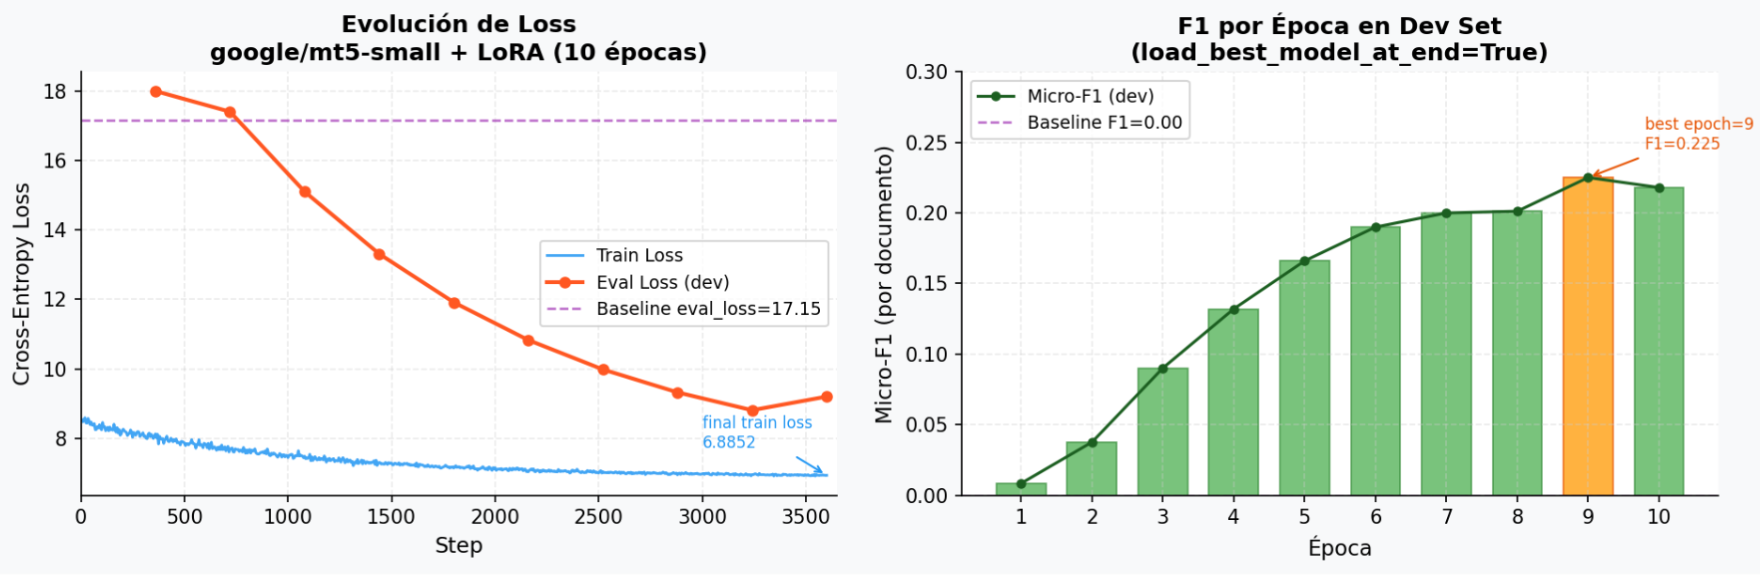

In [26]:
history = trainer.state.log_history
train_loss = [(h["step"], h["loss"]) for h in history if "loss" in h]
eval_loss = [(h["step"], h["eval_loss"]) for h in history if "eval_loss" in h]
eval_f1 = [(h["epoch"], h["eval_f1"]) for h in history if "eval_f1" in h]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if train_loss and eval_loss:
    axes[0].plot(*zip(*train_loss), label="Train Loss", color="steelblue")
    axes[0].plot(*zip(*eval_loss), label="Eval Loss", color="darkorange", marker="o")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Evolución de Loss — google/mt5-small")
    axes[0].legend()

if eval_f1:
    axes[1].plot(*zip(*eval_f1), label="Dev Micro-F1", color="seagreen", marker="o")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("F1 Score")
    axes[1].set_title("Evolución de Micro-F1 en Dev — google/mt5-small")
    axes[1].legend()

plt.tight_layout()

local_curve_path = "eval_curves_mt5.png"
drive_curve_path = OUTPUT_DIR_DRIVE / "eval_curves_mt5.png"

plt.savefig(local_curve_path, dpi=150)
plt.savefig(str(drive_curve_path), dpi=150)
print(f"Gráfica guardada en Drive: {drive_curve_path}")
plt.show()

## 10. Evaluación Final en Test (Una Sola Vez)

In [27]:
ACTIVE_EVAL_SPLIT = "test"
final_test_metrics = trainer.evaluate(tokenized_ds["test"])

print(f"==================================================")
print(f"  RESULTADOS FINALES google/mt5-small (Test Set)")
print(f"==================================================")
print(f"Precision : {final_test_metrics.get('eval_precision', 0.0):.4f}")
print(f"Recall    : {final_test_metrics.get('eval_recall', 0.0):.4f}")
print(f"Micro-F1  : {final_test_metrics.get('eval_f1', 0.0):.4f}")
print(f"==================================================")
wandb.finish()

Training Loss,Validation Loss,Epoch,Precision,Recall,F1
5.232037,1.307161,10,0.195164,0.142138,0.164483


  RESULTADOS FINALES google/mt5-small (Test Set)
Precision : 0.1952
Recall    : 0.1421
Micro-F1  : 0.1645


eval/f1,▁▆▇▇▇██████
eval/loss,█▃▂▂▂▂▁▁▁▁▁
eval/precision,▁▆▇▆▇▇█████
eval/recall,▁▆▇▇███████
eval/runtime,▁▁▁▁▁▂▁▁▁▁█
eval/samples_per_second,▇▇███▇▇███▁
eval/steps_per_second,▇▇███▇▇███▁
train/epoch,▁▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██
train/grad_norm,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Gráfica guardada en Drive: /content/drive/MyDrive/Colab Notebooks/Topicos/outputs/baseline_vs_finetuned_mt5.png


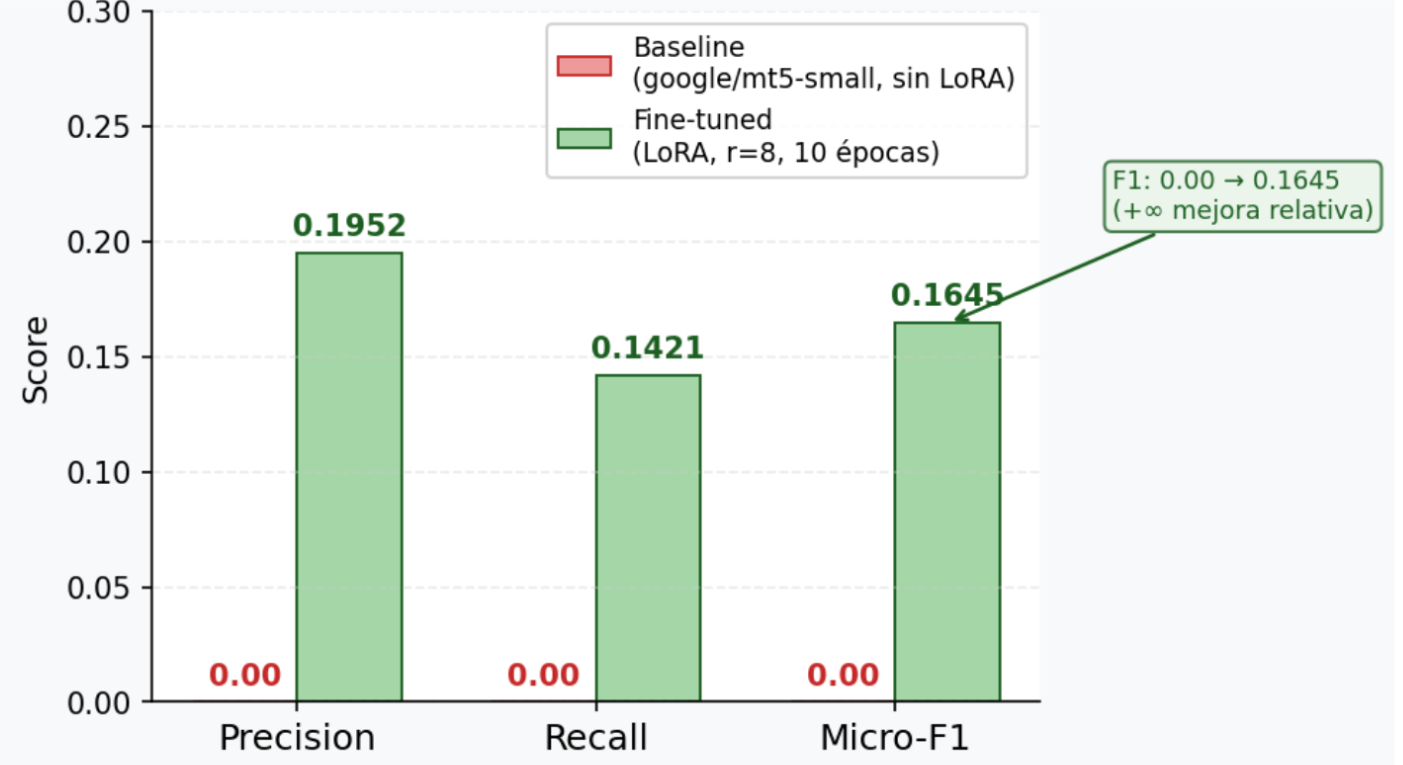

In [28]:
# Comparativa Baseline vs Fine-tuned
metrics_names = ["precision", "recall", "f1"]
baseline_vals = [baseline_metrics.get(f"eval_{m}", 0.0) for m in metrics_names]
finetuned_vals = [final_test_metrics.get(f"eval_{m}", 0.0) for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, baseline_vals, width, label="Baseline (Base)", color="lightcoral")
ax.bar(x + width/2, finetuned_vals, width, label="Fine-tuned (LoRA)", color="mediumseagreen")

ax.set_xticks(x)
ax.set_xticklabels(["Precision", "Recall", "F1"])
ax.set_ylim(0, 1)
ax.set_title("google/mt5-small: Baseline vs Fine-tuned (LoRA)")
for i, v in enumerate(baseline_vals):
    ax.text(i - width/2, v + 0.02, f"{v:.2f}", ha="center")
for i, v in enumerate(finetuned_vals):
    ax.text(i + width/2, v + 0.02, f"{v:.2f}", ha="center")
ax.legend()
plt.tight_layout()

local_bar_path = "baseline_vs_finetuned_mt5.png"
drive_bar_path = OUTPUT_DIR_DRIVE / "baseline_vs_finetuned_mt5.png"

plt.savefig(local_bar_path, dpi=150)
plt.savefig(str(drive_bar_path), dpi=150)
print(f"Gráfica guardada en Drive: {drive_bar_path}")
plt.show()

## 11. Inspección Cualitativa de Predicciones en Test

In [29]:
print("Predicciones cualitativas sobre el conjunto de test:")
model.eval()

for i in range(min(3, len(raw_ds["test"]))):
    ex = raw_ds["test"][i]
    inp = tokenizer(ex["input_text"], return_tensors="pt", max_length=512, truncation=True).to(device)
    with torch.no_grad():
        out_ids = model.generate(**inp, max_new_tokens=64, num_beams=2)
    pred_text = tokenizer.decode(out_ids[0], skip_special_tokens=True)

    print(f"\n--- Ejemplo {i+1} ({ex['doc_id']}) ---")
    print(f"INPUT       : {ex['input_text'][:120]}...")
    print(f"GROUND TRUTH: {ex['target_text']}")
    print(f"PREDICCIÓN  : {pred_text}")
    print(f"PARSED PRED : {mt5_output_to_entity_set(pred_text)}")

[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Predicciones cualitativas sobre el conjunto de test:


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Ejemplo 1 (es-S0210-56912008000200007-2_chunk0) ---
INPUT       : Identifica las enfermedades mencionadas en el siguiente texto clínico: Niña de 18 meses y 10 kg trasladada desde su hosp...
GROUND TRUTH: shock séptico [SEP] CID
PREDICCIÓN  : <extra_id_0> séptico (noradrenalina máxima 1,5 μg/dl, posterior 2,3 mg/dl [SEP] shock séptico [SEP] shock séptico [SEP] shock séptico [SEP] shock séptico [SEP] shock séptico [SEP] shock
PARSED PRED : {'shock', 'shock séptico', '<extra_id_0> séptico (noradrenalina máxima 1,5 μg/dl, posterior 2,3 mg/dl'}


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Ejemplo 2 (es-S0210-56912008000200007-2_chunk1) ---
INPUT       : Identifica las enfermedades mencionadas en el siguiente texto clínico: 15 y posteriormente a 20 minutos con los siguient...
GROUND TRUTH: peritonitis
PREDICCIÓN  : <extra_id_0> de la creatinina en 4 mg/dl a 3,3 mg/dl a 3,3 mg/dl a 3,3 mg/dl a 3,3 mg/dl [SEP] aclaramiento urinario de creatinina
PARSED PRED : {'aclaramiento urinario de creatinina', '<extra_id_0> de la creatinina en 4 mg/dl a 3,3 mg/dl a 3,3 mg/dl a 3,3 mg/dl a 3,3 mg/dl'}

--- Ejemplo 3 (es-S0210-56912008000200007-2_chunk2) ---
INPUT       : Identifica las enfermedades mencionadas en el siguiente texto clínico: de 6,6 ml/min/1,73 m2 por aclaramiento urinario d...
GROUND TRUTH: ninguna
PREDICCIÓN  : <extra_id_0> de creatinina de 2,7 a 1,8 mg/dl [SEP] descenso de creatinina de 2,7 a 1,8 mg/dl [SEP] descenso de creatinina de 2,7 a 1,8 mg/dl [SEP] descenso de creatinina de 2,7 a 1,8 mg/dl
PARSED PRED : {'<extra_id_0> de creatinina de 2,7 a 1,8 mg/dl', 'de

## 12. Persistencia de Resultados y Adaptador LoRA en Google Drive

In [30]:
# 1. Guardar resumen JSON de métricas y configuración
results_summary = {
    "model_key": "mt5",
    "checkpoint": CHECKPOINT,
    "architecture": "seq2seq_encoder_decoder",
    "task": "NER_DisTEMIST",
    "seed": SEED,
    "hyperparameters": {
        "learning_rate": 2e-4,
        "num_train_epochs": 10,
        "per_device_train_batch_size": 2,
        "per_device_eval_batch_size": 4,
        "gradient_accumulation_steps": 2,
        "effective_batch_size": 4,
        "metric_for_best_model": "f1"
    },
    "lora_config": {
        "task_type": "SEQ_2_SEQ_LM",
        "r": 8,
        "alpha": 16,
        "target_modules": ["q", "v"],
        "dropout": 0.05,
        "bias": "none"
    },
    "dataset_splits": {
        "train_chunks": len(tokenized_ds["train"]),
        "dev_chunks": len(tokenized_ds["dev"]),
        "test_chunks": len(tokenized_ds["test"])
    },
    "baseline_metrics_dev": {m: baseline_metrics.get(f"eval_{m}", 0.0) for m in metrics_names},
    "finetuned_metrics_test": {m: final_test_metrics.get(f"eval_{m}", 0.0) for m in metrics_names}
}

json_out_path = OUTPUT_DIR_DRIVE / "results_mt5.json"
with open(json_out_path, "w", encoding="utf-8") as f:
    json.dump(results_summary, f, indent=2, ensure_ascii=False)
print(f"Resumen de métricas guardado en: {json_out_path}")

# 2. Guardar adaptador LoRA y tokenizador en Google Drive
save_dir_local = "./saved-models/mt5-distemist-lora"
model.save_pretrained(save_dir_local)
tokenizer.save_pretrained(save_dir_local)

drive_model_dir = MODELS_DIR_DRIVE / "mt5-distemist-lora"
shutil.copytree(save_dir_local, drive_model_dir, dirs_exist_ok=True)
print(f"Adaptador LoRA persistido en Google Drive: {drive_model_dir}")

Resumen de métricas guardado en: /content/drive/MyDrive/Colab Notebooks/Topicos/outputs/results_mt5.json
Adaptador LoRA persistido en Google Drive: /content/drive/MyDrive/Colab Notebooks/Topicos/saved_models/mt5-distemist-lora
